## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


In [ ]:
your_name = 'Jonathan Cruz'
your_partner_name = ''

#### **Linear Regression with Feature Engineering and Observing Bias-Variance**

In this activity, you will compare **simple linear regression**, **multiple linear regression**, and a **feature-engineered regression model** using the `USA_Housing.csv` dataset.

## **What this notebook focuses on**

This notebook combines two important ideas:

- **Feature engineering**: improving model inputs through scaling, encoding, and interaction features
- **Bias-variance analysis**: understanding model error and prediction stability

## **Why this matters**

A model can perform poorly for different reasons. It may:
- underfit the data (high bias),
- overfit or be unstable (high variance), or
- simply need better feature representations.

By comparing multiple versions of linear regression, you can see how feature choices affect prediction quality and the bias-variance tradeoff.

## **Objectives**

In this activity, you will:
1. Build a simple linear regression baseline
2. Visualize predictions and evaluate error behavior
3. Build a multiple linear regression model
4. Apply feature engineering (scaling, one-hot encoding, and an interaction feature)
5. Compare MSE, bias, and variance before and after feature engineering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

# Load a small section of the dataset
filename = 'USA_Housing.csv'
data = pd.read_csv(filename)
data = data.sample(frac=0.1, random_state=1)  # Use 10% of the data

In [2]:
# remind yourself what the data looks like.
data.head(2)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
2764,75012.341660,6.742828,6.604335,4.10,42877.424147,1.413580e+06,"6218 Parker Crescent\nSouth Kristaside, CA 14710"
4767,76187.273309,6.156222,7.166149,3.32,45084.394236,1.618721e+06,"207 Dillon Knolls\nPort Jesseburgh, FM 27308"


#### **TASK 1: Simple Linear Regression**

Implement a simple linear regression model using the `scikit-learn` library. Use `Avg. Area Income` as your independent variable `X`, and determine the appropriate dependent variable `y` from the dataset.

### **Purpose of this step**

This creates a **baseline model** using only one predictor. A simple model is easier to interpret, but it may miss important information contained in the other features.

As you build it, make sure to:
- select the feature/target correctly,
- split into train/test sets, and
- store predictions for later evaluation and visualization.


In [3]:
# Write your code here
X = data[['Avg. Area Income']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

y_pred_simple = model_simple.predict(X_test)

#### **TASK 2: Visualization**

Implement a scatter plot to visualize the linear regression model you built above.

### **What to visualize**

Plot the test data and overlay the fitted regression line. This helps you visually inspect:
- whether a linear trend is reasonable,
- how far predictions are from actual values, and
- whether there may be patterns the simple model is missing.


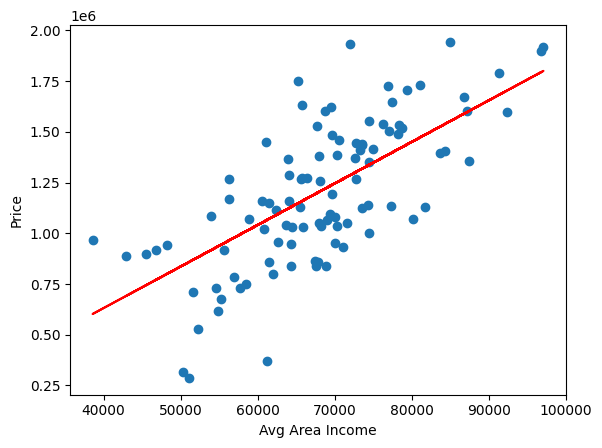

In [8]:
# Write your code here
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_simple, color='red')
plt.xlabel("Avg Area Income")
plt.ylabel("Price")
plt.show()

#### **TASK 3: Bias and Variance**

Measure and print **MSE**, bias, and variance. Bias is the average error between predicted and true values, and variance is the variability of model predictions. For variance, you can use NumPy's `var()` method.

### **Interpretation tip**

This simple model uses only one predictor, so it may show noticeable bias if the target depends on other important variables. Record these values so you can compare them to later models.


In [5]:
# Write your code here
mse = mean_squared_error(y_test, y_pred_simple)
bias = np.mean(y_pred_simple - y_test)
variance = np.var(y_pred_simple)

print(f'MSE: {mse}')
print(f'Bias: {bias}')
print(f'Variance: {variance}')

MSE: 64341717931.45217
Bias: 9110.921573394346
Variance: 52716258218.292015


### **Comments:**

Use this section to interpret the simple linear regression results.

Questions to consider:
- Does the one-feature model appear to underfit the housing data?
- Is the average prediction error (bias) noticeably far from zero?
- How large is the MSE relative to the scale of housing prices?
- How does prediction variance compare to what you expected?

* A relatively weak simple linear model often leaves substantial error because one feature cannot explain housing prices on its own. This is a useful baseline for later comparison with multiple regression and feature-engineered models.


#### **TASK 4: Multiple Linear Regression**

Implement a multiple linear regression model using the `scikit-learn` library.

### **Why move to multiple regression?**

Housing price is influenced by multiple variables. A model using several features typically captures more structure than a one-feature model and can reduce underfitting.

Be sure to exclude non-predictive or non-numeric columns (unless encoded first), such as raw text address fields.


In [ ]:
# Write your code here
X_multi = data.drop(columns=['Price', 'Address'])
y_multi = data['Price']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_multi = model_multi.predict(X_test_m)


#### **TASK 5: Visualize Your Multiple Linear Regression Model**

Implement a scatter plot to visualize the model.

### **Recommended view**

For multiple regression, a common visualization is an **Actual vs Predicted** scatter plot. If predictions are strong, points should cluster near the diagonal reference line.


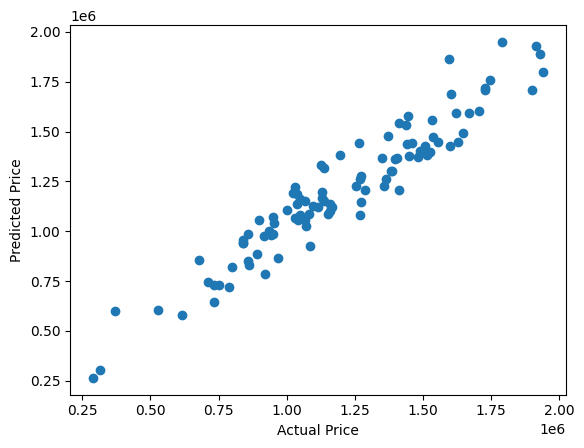

In [9]:
# Write your code here
plt.scatter(y_test_m, y_pred_multi)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

#### **TASK 6: Measure Bias and Variance**

Measure the mean squared error (MSE), bias, and variance for the multiple linear regression model.

### **Why compare these metrics?**

These metrics provide a more complete picture than any single number:
- **MSE** summarizes overall prediction error magnitude
- **Bias** captures average prediction offset (systematic error)
- **Variance** reflects the spread of predictions (stability)

Compare these results to the simple regression model to see what improved and what tradeoffs remain.


In [10]:
# Write your code here
mse_multi = mean_squared_error(y_test_m, y_pred_multi)
bias_multi = np.mean(y_pred_multi - y_test_m)
variance_multi = np.var(y_pred_multi)

print(f'Mean Squared Error (MSE): {mse_multi}')
print(f'Bias: {bias_multi}')
print(f'Variance: {variance_multi}')

Mean Squared Error (MSE): 11156575387.611128
Bias: 5222.369641169077
Variance: 112875488148.16888


### **Comments:**

Interpret your multiple linear regression results here.

Questions to consider:
- How much did MSE improve compared with simple regression?
- Did bias move closer to zero?
- Did variance increase as the model became more expressive?

* Multiple linear regression often improves accuracy by using additional predictors, but it can also increase variance if the model becomes more sensitive to the training sample.


#### **TASK 7: Apply Feature Engineering Techniques**

Apply the following feature engineering steps:
- Scale the numerical features
- One-hot encode the categorical column
- Create an interaction feature named `IncomePopulationInteraction` by multiplying `Avg. Area Income` and `Area Population`
- Train a new multiple linear regression model using the engineered dataset

### **Why these transformations?**

- **Scaling** standardizes numeric feature magnitudes
- **One-hot encoding** converts categorical/text information into model-usable columns
- **Interaction features** allow a linear model to capture combined effects between variables

This step tests whether better feature representations improve predictive performance.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Write your code here

#### **TASK 8: Measure Bias and Variance After Feature Engineering**

Using the feature-engineered dataset, measure and report the MSE, bias, and variance.

### **Comparison goal**

Compare these values against the earlier multiple regression model to evaluate whether feature engineering improved accuracy, reduced bias, or changed prediction variance.


In [ ]:
# Write your code here
mse_after_fe = ...
bias_after_fe = ...
variance_after_fe = ...

print(f'Mean Squared Error (MSE) after Feature Engineering: {mse_after_fe}')
print(f'Bias after Feature Engineering: {bias_after_fe}')
print(f'Variance after Feature Engineering: {variance_after_fe}')

### **Comments:**

Use this section to interpret how feature engineering affected model behavior.

Questions to consider:
- Did MSE improve meaningfully or only slightly?
- Did bias move closer to zero?
- Did variance increase, decrease, or stay high?
- What does that suggest about the bias-variance tradeoff in this dataset?

* After applying feature engineering, the MSE may decrease, indicating improved model accuracy. A reduction in bias suggests the engineered features help capture more of the underlying pattern. However, if variance remains high, the model may still be sensitive to the specific training sample.

* In practice, if variance stays high after feature engineering, consider regularization (such as Ridge/Lasso) or revisiting feature complexity to improve generalization.


In [ ]:
# Visualize the results before and after enhanced feature engineering using subplots
plt.figure(figsize=(12,6))

# Before Feature Engineering
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions_multi) #predictions_multi is what I called mine. change it to what you called it.
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Before Feature Engineering')

# After Enhanced Feature Engineering
plt.subplot(1, 2, 2)
plt.scatter(y_test, predictions_encoded) #predictions_encoded is what I called mine. change it to what you called it.
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)])
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('After Feature Engineering')

plt.tight_layout()
plt.show()

## **Summary and Key Takeaways**

### **What we practiced**

1. **Simple regression baseline**
- Built a one-feature model and visualized its fit

2. **Model evaluation beyond one metric**
- Compared MSE, bias, and variance to understand model behavior

3. **Multiple linear regression**
- Expanded the feature set to improve predictive performance

4. **Feature engineering for tabular regression**
- Scaled numeric features
- One-hot encoded categorical values
- Created an interaction feature to capture combined effects

5. **Before/after comparison**
- Evaluated whether engineered features improved accuracy and changed the bias-variance tradeoff

### **Best Practices**

- Start with a simple baseline before adding complexity
- Compare models using multiple evaluation metrics, not just one
- Use feature engineering to make patterns easier for the model to learn
- Watch for increased variance as model complexity grows
- Interpret improvements in terms of both accuracy and generalization
